### Attribution with TorchCAM

In [1]:
from torchvision.io import decode_image
from torchvision.models import get_model, get_model_weights
from torchcam.methods import LayerCAM

weights = get_model_weights("resnet18").DEFAULT
model = get_model("resnet18", weights=weights).eval()

preprocess = weights.transforms()

#img = decode_image("data/rus.webp")
#img = decode_image("data/horse.jpg")
img = decode_image("images/Yoda.jpg")

input_tensor = preprocess(img)

with LayerCAM(model) as cam_extractor:
    out = model(input_tensor.unsqueeze(0))
    activation_map = cam_extractor(out.squeeze(0).argmax().item(), out)

In [2]:
#model

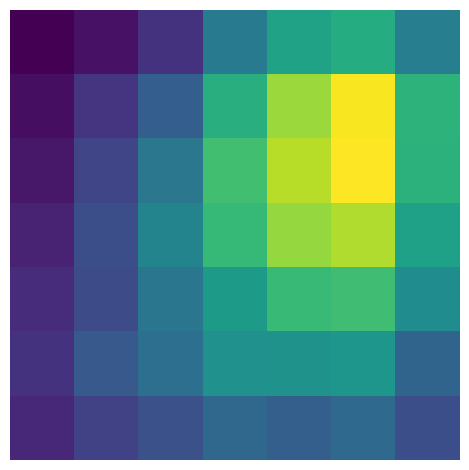

In [3]:
import matplotlib.pyplot as plt

plt.imshow(activation_map[0].squeeze(0).numpy())
plt.axis("off")
plt.tight_layout()
plt.show()

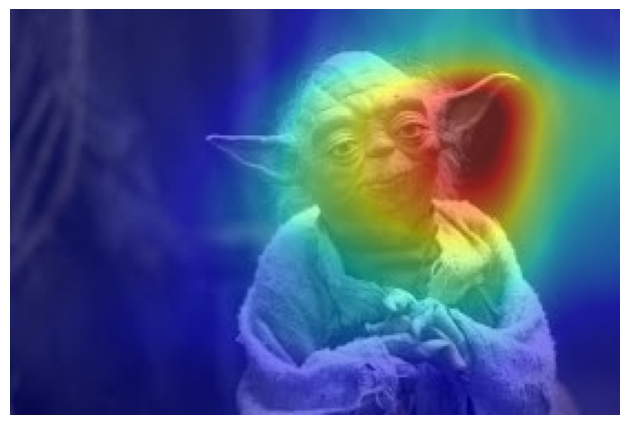

In [4]:
from torchvision.transforms.v2.functional import to_pil_image
from torchcam.utils import overlay_mask

result = overlay_mask(to_pil_image(img), to_pil_image(activation_map[0].squeeze(0), mode='F'), alpha=0.5)
plt.imshow(result)
plt.axis('off')
plt.tight_layout()
plt.show()

In [5]:
#> claude.ai
#> I have a json file with class names (imagenet_class_index.json) from 1000 classes in ImageNet and an output 
#  tensor from a ResNet18 (with default pretrained weights) softmax operation. 
#  Give a function that maps the maximum logit in the output tensor to the class name from the json file.

import json
import torch

def predict_class(output_tensor: torch.Tensor, class_index_path: str) -> dict:
    """
    Maps the maximum logit in a softmax output tensor to an ImageNet class name.

    Args:
        output_tensor:    1D or 2D tensor of shape (1000,) or (1, 1000),
                          typically the output of a softmax layer from ResNet18.
        class_index_path: Path to the imagenet_class_index.json file.

    Returns:
        A dict with keys:
            - 'class_index'  (int)   : index of the predicted class (0–999)
            - 'class_id'     (str)   : WordNet synset ID, e.g. "n01440764"
            - 'class_name'   (str)   : human-readable label, e.g. "tench"
            - 'confidence'   (float) : softmax probability of the top class
    """
    with open(class_index_path, "r") as f:
        class_index = json.load(f)  # keys are str "0".."999"

    # Flatten to 1-D in case the tensor has a batch dimension
    probs = output_tensor.squeeze()          # (1000,)
    if probs.ndim != 1 or probs.shape[0] != 1000:
        raise ValueError(
            f"Expected a tensor of 1000 values, got shape {tuple(output_tensor.shape)}"
        )

    top_idx = int(probs.argmax())            # index of highest probability
    synset_id, class_name = class_index[str(top_idx)]

    return {
        "class_index": top_idx,
        "class_id":    synset_id,
        "class_name":  class_name,
        "confidence":  float(probs[top_idx]),
    }

In [6]:
model.eval()
batch = preprocess(img).unsqueeze(0)
prediction = model(batch).squeeze(0).softmax(0)

In [7]:
predict_class(prediction.detach(), "data/imagenet_class_index.json")

{'class_index': 367,
 'class_id': 'n02481823',
 'class_name': 'chimpanzee',
 'confidence': 0.5521905422210693}